In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
from sklearn import feature_selection
import pandas as pd
import numpy as np
import random

In [2]:
# change the threshold of classitfying

In [9]:
def make_class(x,n,save=False):

    #x is the train dataframe
    #n is the threshold--------------0 is bad;1 is good
    #is the excel you want to save

    c = x.iloc[:, -1] < n
    c = pd.DataFrame(c)
    c.columns = ['class']
    c_ = []
    for i in c.loc[:, 'class']:
        i = int(i)
        c_.append(i)
    c_ = pd.DataFrame(c_)
    c_.columns = ['class']
    data1 = x.iloc[:,:-1].copy()
    data_class = pd.concat([data1, c_], axis=1)
    print('the number of good AEM is',c_.sum())
    if save==True:
        data_class.to_excel(r'classification_threshold/data_class_'+str(n)+'.xlsx', index=False)

In [10]:
x0 = pd.read_excel("train_degration.xlsx")
make_class(x0,0.0001,True)
make_class(x0,0.1,True)
make_class(x0,1,True)
make_class(x0,10,True)

the number of good AEM is class    185
dtype: int64
the number of good AEM is class    186
dtype: int64
the number of good AEM is class    234
dtype: int64
the number of good AEM is class    399
dtype: int64


In [17]:
a1 = pd.read_excel(r'train_data/train_descriptor_class_new.xlsx')
a2 = pd.read_excel(r'train_data/train_fingerprint_class_new.xlsx')

for threshold in [0.0001, 0.1, 1, 10]:
    b = pd.read_excel(r'classification_threshold/data_class_'+str(threshold)+'.xlsx')
    a1.iloc[:, -1] = b.iloc[:, -1].values
    a2.iloc[:, -1] = b.iloc[:, -1].values
    
    a1.to_excel(r'classification_threshold/data_class_d_'+str(threshold)+'.xlsx', index=False)
    a2.to_excel(r'classification_threshold/data_class_f_'+str(threshold)+'.xlsx', index=False)

In [19]:
d_train1 = pd.read_excel(r"classification_threshold/data_class_d_1.xlsx")
d_train10 = pd.read_excel(r"classification_threshold/data_class_d_10.xlsx")
d_train01 = pd.read_excel(r"classification_threshold/data_class_d_0.1.xlsx")
d_train04 = pd.read_excel(r"classification_threshold/data_class_d_0.0001.xlsx")
f_train1 = pd.read_excel(r"classification_threshold/data_class_f_1.xlsx")
f_train10 = pd.read_excel(r"classification_threshold/data_class_f_10.xlsx")
f_train01 = pd.read_excel(r"classification_threshold/data_class_f_0.1.xlsx")
f_train04 = pd.read_excel(r"classification_threshold/data_class_f_0.0001.xlsx")

In [21]:
scaler_d = StandardScaler()
x = d_train1.iloc[:,2:-1]
d_standard=pd.DataFrame(scaler_d.fit_transform(x))
d_standard.columns = x.columns
d_standard

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,...,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF,Concentration,Temperature,Time(h)
0,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,-1.024348,-2.792176,-0.154244
1,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,0.698211,-2.792176,-0.154244
2,-0.956010,-0.956010,-1.012491,0.696014,-0.618767,-0.746074,-0.767408,0.0,0.565477,0.588061,...,0.425590,-0.304484,1.759717,0.711897,1.438407,-1.260962,-1.415595,3.569143,-2.792176,-0.154244
3,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,-1.041870,-2.792176,-0.154244
4,-0.709068,-0.709068,-0.901994,0.523286,-0.554097,-0.608455,-0.613299,0.0,0.661719,0.617697,...,0.419622,-0.432428,0.315941,0.438906,0.157161,-0.265421,-0.306604,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.327705,0.327705,-0.236766,0.011338,0.176289,-0.244850,-0.253711,0.0,-0.842798,-0.430127,...,0.078053,-0.189725,-0.254645,0.451880,0.179949,-0.283907,-0.257171,-0.149900,-1.051537,-0.108249
880,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.682822,0.108888,-0.058072
881,1.029078,1.029078,-0.356094,-0.490633,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,1.154870,4.880384,-0.745805,0.803179,2.878754,-1.834047,-0.108908,-0.149900,0.689101,-0.120793
882,1.044433,1.044433,-0.317078,-0.497874,-0.596614,2.270177,2.212036,0.0,-0.963843,-0.535560,...,0.894063,4.629009,-0.996935,0.792490,2.523561,-1.856980,-0.303821,-0.682822,0.108888,-0.058072


In [22]:
scaler_f = StandardScaler()
x = f_train1.iloc[:,2:-1]
f_standard=pd.DataFrame(scaler_f.fit_transform(x))
f_standard.columns = x.columns
f_standard

,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,MACCS-8,MACCS-9,...,MACCS-160,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h)
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.024348,-2.792176,-0.154244
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.698211,-2.792176,-0.154244
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,3.569143,-2.792176,-0.154244
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.041870,-2.792176,-0.154244
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,-1.051537,-0.108249
880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072
881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,0.689101,-0.120793
882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072


In [25]:
import xgboost as xgb
ftrain1=xgb.DMatrix(f_standard,f_train1.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}
n_estimators=250
model_f1=xgb.train(param0,ftrain1,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:51:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [27]:
ftrain10=xgb.DMatrix(f_standard,f_train10.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}
n_estimators=250
model_f10=xgb.train(param0,ftrain10,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:52:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [29]:
ftrain01=xgb.DMatrix(f_standard,f_train01.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}
n_estimators=250
model_f01=xgb.train(param0,ftrain01,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:52:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [30]:
ftrain04=xgb.DMatrix(f_standard,f_train04.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}
n_estimators=250
model_f04=xgb.train(param0,ftrain04,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:53:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [33]:
dtrain1=xgb.DMatrix(d_standard,d_train1.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':6
            ,'random_state':0}
n_estimators=200
model_d1=xgb.train(param0,dtrain1,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:53:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [34]:
dtrain10=xgb.DMatrix(d_standard,d_train10.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':6
            ,'random_state':0}
n_estimators=200
model_d10=xgb.train(param0,dtrain10,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:53:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [37]:
dtrain01=xgb.DMatrix(d_standard,d_train01.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':6
            ,'random_state':0}
n_estimators=200
model_d01=xgb.train(param0,dtrain01,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:53:43] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [38]:
dtrain04=xgb.DMatrix(d_standard,d_train04.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':6
            ,'random_state':0}
n_estimators=200
model_d04=xgb.train(param0,dtrain04,n_estimators)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:53:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


In [58]:
ftest1 = xgb.DMatrix(f_standard)
pred_f1=model_f1.predict(ftest1)
pre_f1 = pd.DataFrame(pred_f1)

ftest10 = xgb.DMatrix(f_standard)
pred_f10=model_f10.predict(ftest10)
pre_f10 = pd.DataFrame(pred_f10)

ftest01 = xgb.DMatrix(f_standard)
pred_f01=model_f01.predict(ftest01)
pre_f01 = pd.DataFrame(pred_f01)

ftest04 = xgb.DMatrix(f_standard)
pred_f04=model_f04.predict(ftest04)
pre_f04 = pd.DataFrame(pred_f04)

dtest1 = xgb.DMatrix(d_standard)
pred_d1=model_d1.predict(dtest1)
pre_d1 = pd.DataFrame(pred_d1)

dtest10 = xgb.DMatrix(d_standard)
pred_d10=model_d10.predict(dtest10)
pre_d10 = pd.DataFrame(pred_d10)

dtest01 = xgb.DMatrix(d_standard)
pred_d01=model_d01.predict(dtest01)
pre_d01 = pd.DataFrame(pred_d01)

dtest04 = xgb.DMatrix(d_standard)
pred_d04=model_d04.predict(dtest04)
pre_d04 = pd.DataFrame(pred_d04)

In [60]:
ypred_f1 = pred_f1.copy()
ypred_f1[pred_f1 >0.51]=1
ypred_f1[ypred_f1!=1]=0

ypred_f10 = pred_f10.copy()
ypred_f10[pred_f10 >0.51]=1
ypred_f10[ypred_f10!=1]=0

ypred_f01 = pred_f01.copy()
ypred_f01[pred_f01 >0.51]=1
ypred_f01[ypred_f01!=1]=0

ypred_f04 = pred_f04.copy()
ypred_f04[pred_f04 >0.51]=1
ypred_f04[ypred_f04!=1]=0

ypred_d1 = pred_d1.copy()
ypred_d1[pred_d1 >0.55]=1
ypred_d1[ypred_d1!=1]=0

ypred_d10 = pred_d10.copy()
ypred_d10[pred_d10 >0.55]=1
ypred_d10[ypred_d10!=1]=0

ypred_d01 = pred_d01.copy()
ypred_d01[pred_d01 >0.55]=1
ypred_d01[ypred_d01!=1]=0

ypred_d04 = pred_d04.copy()
ypred_d04[pred_d04 >0.55]=1
ypred_d04[ypred_d04!=1]=0

In [45]:
import graph

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

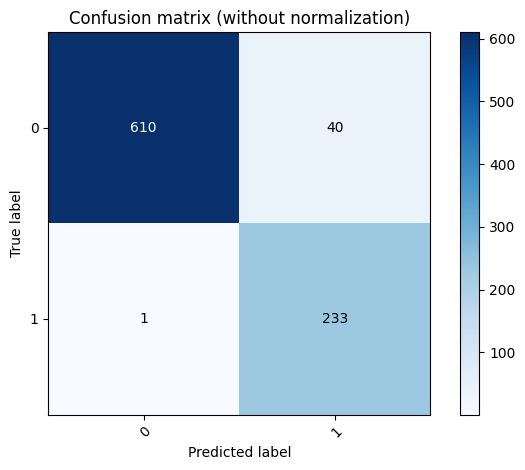

In [64]:
graph.plot_confusion_matrix(d_train1.iloc[:,-1],ypred_d1,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

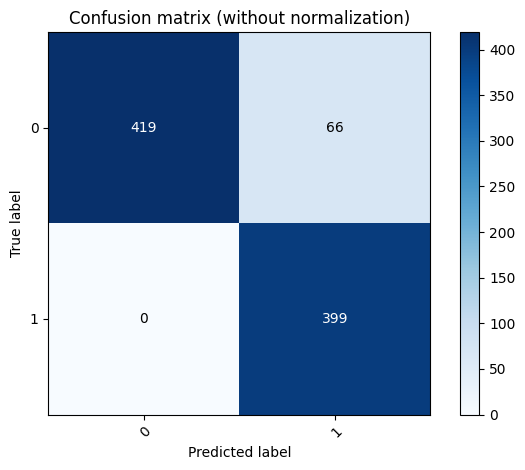

In [65]:
graph.plot_confusion_matrix(d_train10.iloc[:,-1],ypred_d10,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

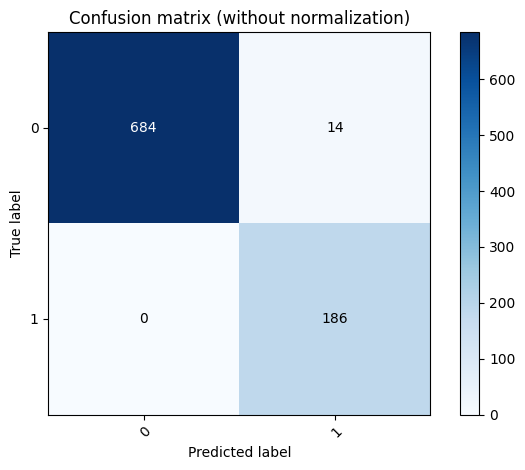

In [66]:
graph.plot_confusion_matrix(d_train01.iloc[:,-1],ypred_d01,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

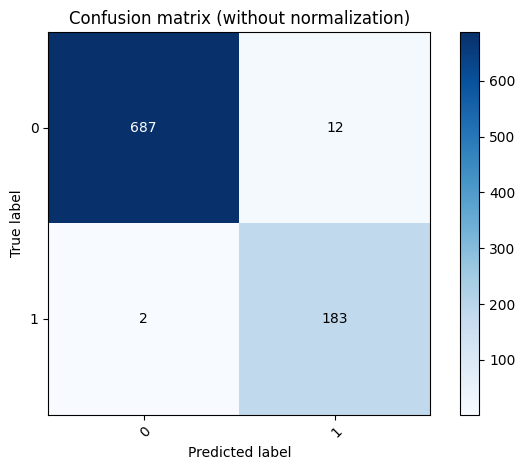

In [67]:
graph.plot_confusion_matrix(d_train04.iloc[:,-1],ypred_d04,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

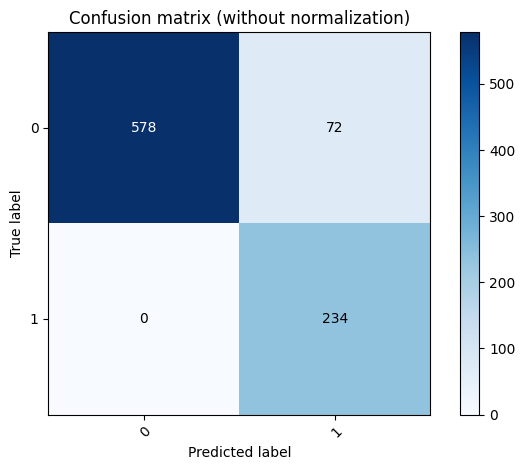

In [72]:
graph.plot_confusion_matrix(f_train1.iloc[:,-1],ypred_f1,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

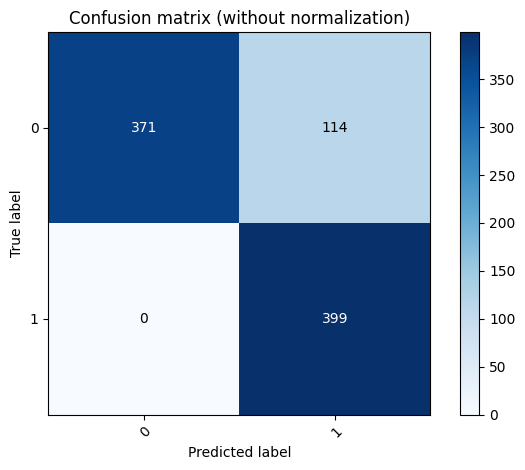

In [73]:
graph.plot_confusion_matrix(f_train10.iloc[:,-1],ypred_f10,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

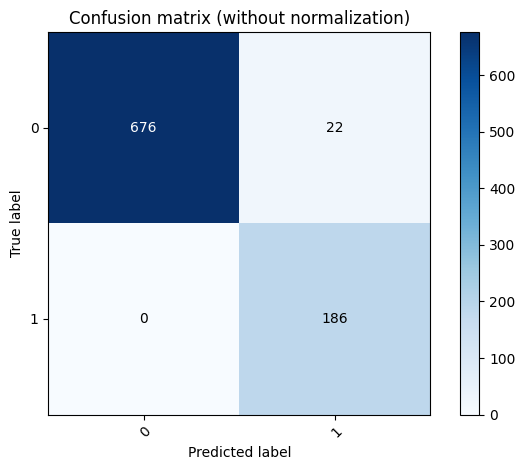

In [76]:
graph.plot_confusion_matrix(f_train01.iloc[:,-1],ypred_f01,np.array(["0","1"]))

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

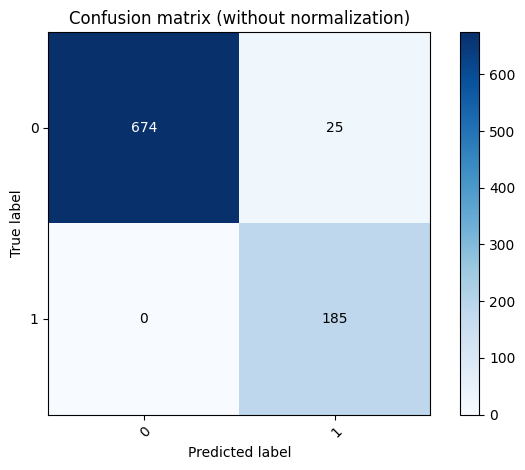

In [77]:
graph.plot_confusion_matrix(f_train04.iloc[:,-1],ypred_f04,np.array(["0","1"]))

In [81]:
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
)

In [92]:
acc = accuracy_score(d_train1.iloc[:,-1],ypred_d1)

fpr, tpr, _ = roc_curve(d_train1.iloc[:,-1],ypred_d1)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9536199095022625 0.9670940170940171


In [93]:
acc = accuracy_score(d_train10.iloc[:,-1],ypred_d10)

fpr, tpr, _ = roc_curve(d_train10.iloc[:,-1],ypred_d10)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9253393665158371 0.931958762886598


In [94]:
acc = accuracy_score(d_train01.iloc[:,-1],ypred_d01)

fpr, tpr, _ = roc_curve(d_train01.iloc[:,-1],ypred_d01)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9841628959276018 0.9899713467048711


In [95]:
acc = accuracy_score(d_train04.iloc[:,-1],ypred_d04)

fpr, tpr, _ = roc_curve(d_train04.iloc[:,-1],ypred_d04)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9841628959276018 0.9860109036074702


In [100]:
acc = accuracy_score(f_train1.iloc[:,-1],ypred_f1)

fpr, tpr, _ = roc_curve(f_train1.iloc[:,-1],ypred_f1)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.918552036199095 0.9446153846153846


In [102]:
acc = accuracy_score(f_train10.iloc[:,-1],ypred_f10)

fpr, tpr, _ = roc_curve(f_train10.iloc[:,-1],ypred_f10)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.8710407239819005 0.8824742268041237


In [104]:
acc = accuracy_score(f_train01.iloc[:,-1],ypred_f01)

fpr, tpr, _ = roc_curve(f_train01.iloc[:,-1],ypred_f01)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9751131221719457 0.984240687679083


In [106]:
acc = accuracy_score(f_train04.iloc[:,-1],ypred_f04)

fpr, tpr, _ = roc_curve(f_train04.iloc[:,-1],ypred_f04)
roc_auc = auc(fpr, tpr)

print(acc, roc_auc)

0.9717194570135747 0.9821173104434907


In [1]:
#-------------------------------------------according to the part of cations to k-fold test------------------------

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score
)

from sklearn.preprocessing import StandardScaler

import xgboost as xgb

# =========================
# 数据读取
# =========================

data_train0 = pd.read_excel(
    "train_descriptor_class_new.xlsx"
)

# 特征
x = data_train0.iloc[:,2:-1]

# 标签
y = data_train0.iloc[:,-1]

# 分组（非常关键）
groups = data_train0.iloc[:,1]

# =========================
# 标准化
# =========================

scaler = StandardScaler()
x_standard = scaler.fit_transform(x)

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


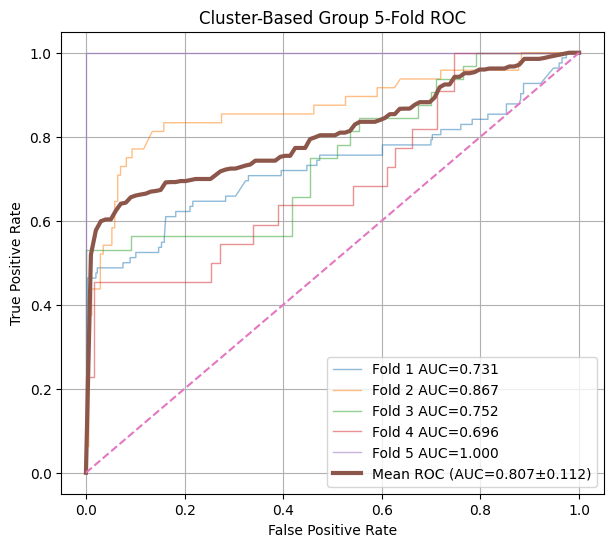


========== Cluster Group 5-Fold ==========

ROC-AUC           : 0.8090 ± 0.1115
PR-AUC            : 0.7266 ± 0.1463
Accuracy          : 0.8843 ± 0.0674
Balanced Accuracy : 0.7717 ± 0.1261
Precision         : 0.9073 ± 0.0963
Recall            : 0.5611 ± 0.2510
F1-score          : 0.6602 ± 0.2009
MCC               : 0.6442 ± 0.1920


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

import xgboost as xgb

# =========================
# 数据读取
# =========================

data_train0 = pd.read_excel(
    "train_descriptor_class_new.xlsx"
)

# 特征
x = data_train0.iloc[:,2:-1]

# 标签
y = data_train0.iloc[:,-1]

# =========================
# 标准化
# =========================

scaler = StandardScaler()

x_standard = scaler.fit_transform(x)

# =========================
# KMeans 聚类
# =========================

n_clusters = 5

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=982,
    n_init=10
)

cluster_labels = kmeans.fit_predict(x_standard)

# groups = cluster labels
groups = cluster_labels

# =========================
# Group K-Fold
# =========================

gkf = GroupKFold(
    n_splits=5
)

# =========================
# 保存指标
# =========================

auc_list = []
pr_auc_list = []
acc_list = []
precision_list = []
recall_list = []
f1_list = []
mcc_list = []
balanced_acc_list = []

# ROC curve
mean_fpr = np.linspace(0,1,100)
tprs = []

plt.figure(figsize=(7,6))

# =========================
# Cross Validation
# =========================

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(x_standard, y, groups)
):

    X_train = x_standard[train_idx]
    X_test = x_standard[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # XGBoost format
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # =========================
    # XGBoost Parameters
    # =========================

    param = {
        'objective':'binary:logistic',
        'eval_metric':'auc',
        'max_depth':4,
        'eta':0.05,
        'subsample':1,
        'colsample_bytree':1,
        'gamma':0,
        'lambda':0,
        'alpha':0,
        'scale_pos_weight':6,
        'random_state':0
    }

    # =========================
    # Train
    # =========================

    model = xgb.train(
        param,
        dtrain,
        num_boost_round=200
    )

    # =========================
    # Predict
    # =========================

    y_prob = model.predict(dtest)

    y_pred = (y_prob > 0.55).astype(int)

    # =========================
    # ROC-AUC
    # =========================

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    auc_list.append(roc_auc)

    interp_tpr = np.interp(
        mean_fpr,
        fpr,
        tpr
    )

    interp_tpr[0] = 0.0

    tprs.append(interp_tpr)

    plt.plot(
        fpr,
        tpr,
        lw=1,
        alpha=0.5,
        label=f'Fold {fold+1} AUC={roc_auc:.3f}'
    )

    # =========================
    # PR-AUC
    # =========================

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = auc(
        recall_curve,
        precision_curve
    )

    pr_auc_list.append(pr_auc)

    # =========================
    # Classification Metrics
    # =========================

    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    mcc = matthews_corrcoef(y_test, y_pred)

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    acc_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    mcc_list.append(mcc)
    balanced_acc_list.append(balanced_acc)

# =========================
# Mean ROC
# =========================

mean_tpr = np.mean(tprs, axis=0)

mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

std_auc = np.std(auc_list)

plt.plot(
    mean_fpr,
    mean_tpr,
    lw=3,
    label=f'Mean ROC (AUC={mean_auc:.3f}±{std_auc:.3f})'
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Cluster-Based Group 5-Fold ROC"
)

plt.legend()

plt.grid()

plt.savefig(
    "cluster_group_5fold_ROC.png",
    dpi=600
)

plt.show()

# =========================
# 输出结果
# =========================

print("\n========== Cluster Group 5-Fold ==========\n")

print(f"ROC-AUC           : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")

print(f"PR-AUC            : {np.mean(pr_auc_list):.4f} ± {np.std(pr_auc_list):.4f}")

print(f"Accuracy          : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")

print(f"Balanced Accuracy : {np.mean(balanced_acc_list):.4f} ± {np.std(balanced_acc_list):.4f}")

print(f"Precision         : {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")

print(f"Recall            : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")

print(f"F1-score          : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")

print(f"MCC               : {np.mean(mcc_list):.4f} ± {np.std(mcc_list):.4f}")